In [1]:

import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [1]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

NameError: name 'torch' is not defined

In [4]:
df = pd.read_csv("output/training_data.csv")


In [5]:
COL_SALE_DATE  = "SALE DATE"
df[COL_SALE_DATE] = pd.to_datetime(df[COL_SALE_DATE], errors='coerce')

In [6]:
# Extract year and month
df['year'] = df[COL_SALE_DATE].dt.year
df['month'] = df[COL_SALE_DATE].dt.month


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263300 entries, 0 to 263299
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   SALE DATE   263300 non-null  datetime64[ns]
 1   BLOCK       263300 non-null  int64         
 2   LOT         263300 non-null  int64         
 3   YEAR BUILT  263300 non-null  int64         
 4   ZIP CODE    263300 non-null  int64         
 5   SALE PRICE  263300 non-null  int64         
 6   year        263300 non-null  int32         
 7   month       263300 non-null  int32         
dtypes: datetime64[ns](1), int32(2), int64(5)
memory usage: 14.1 MB


In [8]:
sum(df.duplicated(df.columns))

2225

In [9]:
#Delete the duplicates and check that it worked
df = df.drop_duplicates(df.columns, keep='last')
sum(df.duplicated(df.columns))

0

In [10]:
df.describe()

,SALE DATE,BLOCK,LOT,YEAR BUILT,ZIP CODE,SALE PRICE,year,month
count,261075,261075.000000,261075.000000,261075.000000,261075.000000,2.610750e+05,261075.000000,261075.000000
mean,2010-06-14 22:51:09.545532672,1124.339650,768.870164,1585.285140,10015.967982,1.842582e+06,2009.951068,6.531736
min,2003-01-01 00:00:00,5.000000,1.000000,0.000000,0.000000,1.000700e+04,2003.000000,1.000000
25%,2006-05-16 00:00:00,850.000000,31.000000,1907.000000,10014.000000,4.290000e+05,2006.000000,4.000000
50%,2010-01-15 00:00:00,1158.000000,1007.000000,1930.000000,10021.000000,7.593590e+05,2010.000000,7.000000
75%,2014-07-16 00:00:00,1444.000000,1220.000000,1965.000000,10027.000000,1.525000e+06,2014.000000,9.000000
max,2018-11-30 00:00:00,2250.000000,9117.000000,2017.000000,10463.000000,4.111112e+09,2018.000000,12.000000
std,NaN,497.331154,853.618598,761.978431,376.192697,1.756430e+07,4.615532,3.322470


In [11]:
# Filter out empty zip codes
df = df[df['ZIP CODE'] != 0.]

In [12]:

X_df = df[['year', 'month', 'BLOCK', 'LOT', 'YEAR BUILT', 'ZIP CODE']]
Y_df = df[['SALE PRICE']]   # Target

In [26]:
X_df

,year,month,BLOCK,LOT,YEAR BUILT,ZIP CODE
0,2015,10,376,24,1900,10009
1,2015,6,377,66,1899,10009
2,2015,6,399,1101,1955,10009
3,2015,11,373,16,1899,10009
4,2015,2,376,7,1900,10009
...,...,...,...,...,...,...
263295,2014,4,2180,1251,2003,10033
263296,2014,6,2180,1252,2003,10033
263297,2014,10,2180,1265,2003,10033
263298,2014,1,2180,1204,2003,10033


In [13]:
# X = torch.cat((tensor_date.unsqueeze(1), temp), dim=1)
X = torch.nn.functional.normalize(torch.tensor(X_df.values, dtype=torch.float32 ), dim=0)
X

tensor([[1.9636e-03, 2.6726e-03, 5.9894e-04, 4.0967e-05, 2.1148e-03, 1.9544e-03],
        [1.9636e-03, 1.6036e-03, 6.0054e-04, 1.1266e-04, 2.1137e-03, 1.9544e-03],
        [1.9636e-03, 1.6036e-03, 6.3558e-04, 1.8793e-03, 2.1760e-03, 1.9544e-03],
        ...,
        [1.9626e-03, 2.6726e-03, 3.4726e-03, 2.1593e-03, 2.2295e-03, 1.9590e-03],
        [1.9626e-03, 2.6726e-04, 3.4726e-03, 2.0552e-03, 2.2295e-03, 1.9590e-03],
        [1.9626e-03, 1.8708e-03, 3.4726e-03, 2.0825e-03, 2.2295e-03, 1.9590e-03]])

In [14]:
Y = torch.nn.functional.normalize(torch.tensor(Y_df.values, dtype=torch.float32), dim=0)
Y

tensor([[4.1853e-04],
        [3.2152e-04],
        [7.7552e-04],
        ...,
        [9.3129e-05],
        [3.3260e-06],
        [5.5434e-06]])

In [15]:

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [16]:
y_train

tensor([[4.5179e-05],
        [2.6720e-06],
        [1.3581e-04],
        ...,
        [7.6786e-05],
        [5.7651e-04],
        [2.7717e-04]])

In [17]:
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)


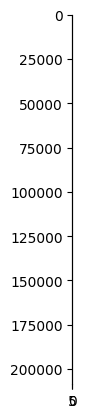

In [18]:
# create a sample tensor
# data = torch.randn(3, 3)

# plot the tensor using Matplotlib
plt.imshow(X_train.cpu())
plt.show()

In [19]:
# Use the nn package to define our model as a sequence of layers. nn.Sequential
# is a Module which contains other Modules, and applies them in sequence to
# produce its output. The Linear Module computes output from input using a
# linear function, and holds internal Tensors for its weight and bias.
# The Flatten layer flatens the output of the linear layer to a 1D tensor,
# to match the shape of `y`.
model = torch.nn.Sequential(
    torch.nn.Linear(6, 1),
    # torch.nn.Flatten(0, 1)
)

model = model.to(device)


In [20]:
@torch.no_grad
def compute_test_loss(model, X_test, y_test):
    
    loss_fn = torch.nn.MSELoss(reduction='sum')

    n = X_test.shape[0]
    
    for t in range(n):
        xx = X_test[t] 
        y = y_test[t]
        
        # predict
        y_pred = model(xx)
        loss = loss_fn(y_pred, y)
        # if t % 1000 == 0:
            # print(t, loss.item())

    return loss.item()
    

In [21]:

# The nn package also contains definitions of popular loss functions; in this
# case we will use Mean Squared Error (MSE) as our loss function.
loss_fn = torch.nn.MSELoss(reduction='sum')

learning_rate = 1e-6
n = X_train.shape[0]
for t in range(n):

    xx = X_train[t]
    
    y = y_train[t]
    
    # Forward pass: compute predicted y by passing x to the model. Module objects
    # override the __call__ operator so you can call them like functions. When
    # doing so you pass a Tensor of input data to the Module and it produces
    # a Tensor of output data.
    y_pred = model(xx)
    
    # Compute and print loss. We pass Tensors containing the predicted and true
    # values of y, and the loss function returns a Tensor containing the
    # loss.
    loss = loss_fn(y_pred, y)
    if t % 10000 == 0:
        print(t, loss.item())
        test_loss = compute_test_loss(model, X_test, y_test)
        print(f"Test Loss: {test_loss}")

    # Zero the gradients before running the backward pass.
    model.zero_grad()

    # Backward pass: compute gradient of the loss with respect to all the learnable
    # parameters of the model. Internally, the parameters of each Module are stored
    # in Tensors with requires_grad=True, so this call will compute gradients for
    # all learnable parameters in the model.
    loss.backward()

    # Update the weights using gradient descent. Each parameter is a Tensor, so
    # we can access its gradients like we did before.
    with torch.no_grad():
        for param in model.parameters():
            param -= learning_rate * param.grad

# You can access the first layer of `model` like accessing the first item of a list
linear_layer = model[0]


0 0.008036728948354721
Test Loss: 0.007914415560662746
10000 0.007375179324299097
Test Loss: 0.0076014259830117226
20000 0.007417378481477499
Test Loss: 0.00730415154248476
30000 0.007077124435454607
Test Loss: 0.007015359587967396
40000 0.006722813937813044
Test Loss: 0.0067406040616333485
50000 0.006471062079071999
Test Loss: 0.006474952679127455
60000 0.0062364679761230946
Test Loss: 0.0062202406115829945
70000 0.006074007600545883
Test Loss: 0.005976131651550531
80000 0.005956755485385656
Test Loss: 0.0057395221665501595
90000 0.005582104437053204
Test Loss: 0.005515454337000847
100000 0.005329042207449675
Test Loss: 0.005297190509736538
110000 0.00522353732958436
Test Loss: 0.005089223850518465
120000 0.004788700956851244
Test Loss: 0.004889538511633873
130000 0.004807131364941597
Test Loss: 0.0046955798752605915
140000 0.0044900206848979
Test Loss: 0.004512247629463673
150000 0.00432834355160594
Test Loss: 0.004334260709583759
160000 0.004211011342704296
Test Loss: 0.004162517376

In [22]:

# For linear layer, its parameters are stored as `weight` and `bias`.
print(f'Result:  bias = {linear_layer.bias.item()} + weight {linear_layer.weight} ')

Result:  bias = 0.05944060906767845 + weight Parameter containing:
tensor([[ 0.1147,  0.2114,  0.3303, -0.3278, -0.3388, -0.3070]],
       device='mps:0', requires_grad=True) 


In [23]:
linear_layer.bias.item()


0.05944060906767845

In [24]:
linear_layer.weight

Parameter containing:
tensor([[ 0.1147,  0.2114,  0.3303, -0.3278, -0.3388, -0.3070]],
       device='mps:0', requires_grad=True)

In [25]:
# Original mean and standard deviation
mean = torch.mean(df, dim=0)
stddev = torch.std(df, dim=0)

TypeError: mean() received an invalid combination of arguments - got (DataFrame, dim=int), but expected one of:
 * (Tensor input, *, torch.dtype dtype = None, Tensor out = None)
 * (Tensor input, tuple of ints dim, bool keepdim = False, *, torch.dtype dtype = None, Tensor out = None)
 * (Tensor input, tuple of names dim, bool keepdim = False, *, torch.dtype dtype = None, Tensor out = None)


In [ ]:
mean

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")